# README

How Experimental and Calculated Data should be available:\
Everything should be inside the the set reweight folder.\
Every data file should be named like this:\
`[exp|calc]_[DATATAG].dat`\
\
Datatag: can be the type of data NOE, CCR...\
Datatag of corresponding experimental files should be the same!\
Example files for CCR:
```
exp_ccr_loop_bme.dat
calc_ccr_loop_bme.dat

```

# Import libraries and define functions

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lib import BME as BME
from lib.rmse import *
import matplotlib as mpl
mpl.rcParams['hatch.linewidth'] = 5

# Load

In [9]:

BME_FOLDER = "bme_reweight"
bundles = ["2_2"]

# Experimental
rdc_exp = np.loadtxt(f"{BME_FOLDER}/exp_rdc_bme.dat",usecols=[1,2])
hcch_exp = np.loadtxt(f"{BME_FOLDER}/exp_ccr_HCCH_loop_bme.dat",usecols=[1,2])
hcn_exp = np.loadtxt(f"{BME_FOLDER}/exp_ccr_HCN_loop_bme.dat",usecols=[1,2])
hcp_exp = np.loadtxt(f"{BME_FOLDER}/exp_ccr_HCP_loop_bme.dat",usecols=[1,2])
ccr_exp = np.loadtxt(f"{BME_FOLDER}/exp_ccr_loop_bme.dat",usecols=[1,2])
noe_exp = np.loadtxt(f"{BME_FOLDER}/exp_noe_loop_bme.dat",usecols=[1,2])
j3_exp = np.loadtxt( f"{BME_FOLDER}/exp_j3_bme.dat",usecols=[1,2])


# Calculated
rdc_calc = np.loadtxt(f"{BME_FOLDER}/calc_rdc_bme.dat")[:,1:]
hcch_calc = np.loadtxt(f"{BME_FOLDER}/calc_ccr_HCCH_loop_bme.dat")[:,1:]
hcn_calc = np.loadtxt(f"{BME_FOLDER}/calc_ccr_HCN_loop_bme.dat")[:,1:]
hcp_calc = np.loadtxt(f"{BME_FOLDER}/calc_ccr_HCP_loop_bme.dat")[:,1:]
calc = np.loadtxt(f"{BME_FOLDER}/calc_ccr_loop_bme.dat")[:,1:]
noe_calc = np.loadtxt(f"{BME_FOLDER}/calc_noe_loop_bme.dat")[:,1:]
j3_calc = np.loadtxt(f"{BME_FOLDER}/calc_j3_bme.dat")[:,1:]

# Load Data

## RDC

In [3]:
rdc_lbl  = list(pd.read_csv(f'exp_data/exp_rdc_pales.tab', delim_whitespace=True, usecols=[0]).index)
rdc_exp  = np.loadtxt(f'exp_data/exp_rdc_loop_bme.dat', usecols=[1,2])
rdc_calc = np.loadtxt(f'calc_data/calc_rdc_loop_bme.dat')[:,1:]
rdc_exp_all = np.loadtxt(f'exp_data/exp_rdc_bme.dat', usecols=[1,2])
rdc_calc_all = np.loadtxt(f'calc_data/calc_rdc_bme.dat')[:,1:]
L_calc = np.sum(rdc_exp_all[:,0]*np.average(rdc_calc_all, axis=0))/np.sum(np.average(rdc_calc_all, axis=0)*np.average(rdc_calc_all, axis=0))
print('L_calc = ', L_calc)

rdc_bundles = {}
L_bundles = {}
for f in bundles:
    rdc_bundles[f] = np.loadtxt(f'nmrbundle_data/nmrbundle_{f}_rdc_loop_bme.dat')[:,1:]
    L_bundles[f] = np.load(f'nmrbundle_data/nmrbundle_{f}_rdc_all_bme_L.npy') 


L_calc =  0.5969455094450525


## $^3$J

In [4]:
j3_lbl  = list(pd.read_csv(f'exp_data/exp_j3_bme.dat', delim_whitespace=True, usecols=[0]).index)
j3_lbl = [ f"{i.split('-')[0]}:{i.split('-')[1]}" for i in j3_lbl ]
j3_exp   = np.loadtxt(f'exp_data/exp_j3_bme.dat', usecols=[1,2])
j3_calc  = np.loadtxt(f'calc_data/calc_j3_bme.dat')[:,1:]
j3_bundles = {}
for f in bundles:
    j3_bundles[f] = np.loadtxt(f'nmrbundle_data/nmrbundle_{f}_j3_loop_bme.dat')[:,1:]

## CCR

In [5]:
ccr = "HCCH"
ccr_HCCH_lbl  = list(pd.read_csv(f'exp_data/exp_ccr_{ccr}.dat', delim_whitespace=True, usecols=[0]).index)
ccr_HCCH_lbl = [ f"{i.split(':')[0]}:{i.split(':')[1]}" for i in ccr_HCCH_lbl ]
ccr_HCCH_exp  = np.loadtxt(f'exp_data/exp_ccr_{ccr}.dat', usecols=[1,2])
ccr_HCCH_calc = np.loadtxt(f'calc_data/calc_ccr_{ccr}_loop_bme.dat')[:,1:]
ccr_HCCH_bundles = {}
for f in bundles:
    ccr_HCCH_bundles[f] = np.loadtxt(f'nmrbundle_data/nmrbundle_{f}_ccr_calc_{ccr}_loop_bme.dat',skiprows=1)[:,1:]

In [6]:
ccr = "HCN"
ccr_HCN_lbl  = list(pd.read_csv(f'exp_data/exp_ccr_{ccr}.dat', delim_whitespace=True, usecols=[0]).index)
ccr_HCN_lbl = [ f"{i.split(':')[0]}:{i.split(':')[1]}" for i in ccr_HCN_lbl ]
ccr_HCN_exp  = np.loadtxt(f'exp_data/exp_ccr_{ccr}.dat', usecols=[1,2])
ccr_HCN_calc = np.loadtxt(f'calc_data/calc_ccr_{ccr}_loop_bme.dat')[:,1:]
ccr_HCN_bundles = {}
for f in bundles:
    ccr_HCN_bundles[f] = np.loadtxt(f'nmrbundle_data/nmrbundle_{f}_ccr_calc_{ccr}_loop_bme.dat',skiprows=1)[:,1:]

In [7]:
ccr = "HCP"
ccr_HCP_lbl  = list(pd.read_csv(f'exp_data/exp_ccr_{ccr}.dat', delim_whitespace=True, usecols=[0]).index)
ccr_HCP_lbl = [ f"{i.split(':')[0]}:{i.split(':')[1]}" for i in ccr_HCP_lbl ]
ccr_HCP_exp  = np.loadtxt(f'exp_data/exp_ccr_{ccr}.dat', usecols=[1,2])
ccr_HCP_calc = np.loadtxt(f'calc_data/calc_ccr_{ccr}_loop_bme.dat')[:,1:]
ccr_HCP_bundles = {}
for f in bundles:
    ccr_HCP_bundles[f] = np.loadtxt(f'nmrbundle_data/nmrbundle_{f}_ccr_calc_{ccr}_loop_bme.dat',skiprows=1)[:,1:]

## NOE

In [8]:
noe_lbl  = list(pd.read_csv(f'exp_data/exp_noe_loop_bme.dat', delim_whitespace=True, usecols=[0])['#'])
noe_exp = np.loadtxt(f'exp_data/exp_noe_loop_bme.dat', usecols=[1,2])
noe_calc = np.loadtxt(f'calc_data/calc_noe_loop_bme.dat')[:,1:]
noe_bundles = {}
for f in bundles:
    noe_bundles[f] = np.loadtxt(f'nmrbundle_data/nmrbundle_{f}_dists_loop.dat')[:,1:]

# Reweight simulations using
different combination of training sets

# BME Reweighting

## SI Fig: k-fold cross-validation

In [10]:
import glob
import shutil


class Reweighter:
    '''This class has all methods to reweight a given set of weights'''
    def __init__(self, tag, datatags, thetas = None):
        self.rew = BME.Reweight(tag)
        self.tag = tag
        self.thetas = thetas
        # load the experimental and calculated datasets
        for datatag in datatags:
            self.rew.load(
                f"{BME_FOLDER}/exp_{datatag['tag']}.dat",
                f"{BME_FOLDER}/calc_{datatag['tag']}.dat",
                fit=datatag["fit"],
            )
        self.out_dir = f"{BME_FOLDER}/crossvals/crossval_{self.tag}"


    def move_logs(self):
        log_dir = f"{BME_FOLDER}/crossvals/crossval_{self.tag}/logs"
        if not os.path.exists(log_dir):
            os.makedirs(log_dir)

        for file in glob.glob(f"crossval_{self.tag}*.log"):
            shutil.move(file, log_dir)

    def scan_theta(self):
        print(f"Starting to reweight #{self.tag}")
        self.thetas = np.geomspace(
            0.2, 20000, 30
        )  # Start: 0.2 (change if calculation fails at lower range) Stop: 20000, num: 30
        self.rew.theta_scan(thetas=self.thetas, nfold=5)
        print(f"Saving thetas at {self.out_dir}")
        if not os.path.exists(self.out_dir):
            os.makedirs(self.out_dir)
        else:
            print("For this data a result directory already exists, overwriting...")
        np.save(f"{self.out_dir}/thetas.npy",self.thetas)
        return self.thetas

    def save_old_weights(self):
        w_0 = self.rew.get_w0()
        np.save(f"{self.out_dir}/old_weights_results.npy", w_0)

    def reweight_and_save(self):
        if self.thetas is None:
            raise ValueError("Thetas array empty!")
        print("Fitting")
        chi2 = []
        phis = []
        new_weights = []

        for theta in self.thetas:
            chi2_before, chi2_after, phi = self.rew.fit(
                theta=theta
            )  # What does fit do? It does the reweighting duh
            phis.append(phi)
            chi2.append(chi2_after / chi2_before)
            w_new = self.rew.get_weights()
            new_weights.append(w_new)
        print(f"Saving new weights at {self.out_dir}")
        if not os.path.exists(self.out_dir):
            os.makedirs(self.out_dir)
        else:
            print("For this data a result directory already exists, overwriting...")
        np.save(f"{self.out_dir}/chi2_results.npy", chi2)
        np.save(f"{self.out_dir}/phi_results.npy", phis)
        np.save(f"{self.out_dir}/weights_results.npy", new_weights)

## Run BME reweight for different data type combinations

Resulting weights are saved to a corresponding directory in crossvals.
Dataset not included in training sets will be used for cross validation later.

In [11]:
# Tag corresponds to exp and calc file
dt = {
    "hcch": {"tag":"ccr_HCCH_loop_bme", "fit":"no"},
    "hcn": {"tag":"ccr_HCN_loop_bme", "fit":"no"},
    "hcp": {"tag":"ccr_HCP_loop_bme", "fit":"no"},
    "ccr": {"tag":"ccr_loop_bme", "fit":"no"},
    "rdc": {"tag":"rdc_bme", "fit":"scale"},
    "j3": {"tag":"j3_bme", "fit":"no"},
    "noe": {"tag":"noe_loop_bme", "fit":"no"}
}

hcch_j3
[{'tag': 'ccr_HCCH_loop_bme', 'fit': 'no'}, {'tag': 'j3_bme', 'fit': 'no'}]
hcch_rdc
[{'tag': 'ccr_HCCH_loop_bme', 'fit': 'no'}, {'tag': 'rdc_bme', 'fit': 'scale'}]
hcn_rdc
[{'tag': 'ccr_HCN_loop_bme', 'fit': 'no'}, {'tag': 'rdc_bme', 'fit': 'scale'}]
noe_j3
[{'tag': 'noe_loop_bme', 'fit': 'no'}, {'tag': 'j3_bme', 'fit': 'no'}]
hcp_noe
[{'tag': 'ccr_HCP_loop_bme', 'fit': 'no'}, {'tag': 'noe_loop_bme', 'fit': 'no'}]
hcp_j3
[{'tag': 'ccr_HCP_loop_bme', 'fit': 'no'}, {'tag': 'j3_bme', 'fit': 'no'}]
hcp_rdc
[{'tag': 'ccr_HCP_loop_bme', 'fit': 'no'}, {'tag': 'rdc_bme', 'fit': 'scale'}]
noe_j3
[{'tag': 'noe_loop_bme', 'fit': 'no'}, {'tag': 'j3_bme', 'fit': 'no'}]
noe_rdc
[{'tag': 'noe_loop_bme', 'fit': 'no'}, {'tag': 'rdc_bme', 'fit': 'scale'}]
rdc_j3
[{'tag': 'rdc_bme', 'fit': 'scale'}, {'tag': 'j3_bme', 'fit': 'no'}]
hcch_rdc_j3
[{'tag': 'ccr_HCCH_loop_bme', 'fit': 'no'}, {'tag': 'rdc_bme', 'fit': 'scale'}, {'tag': 'j3_bme', 'fit': 'no'}]
hcp_rdc_j3
[{'tag': 'ccr_HCP_loop_bme', 'fi

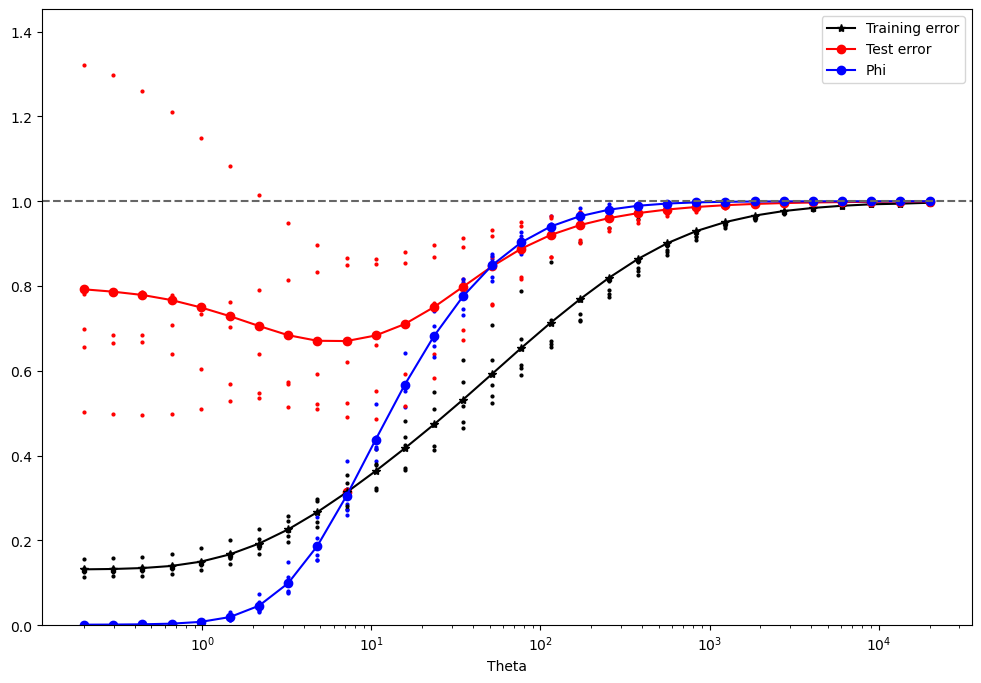

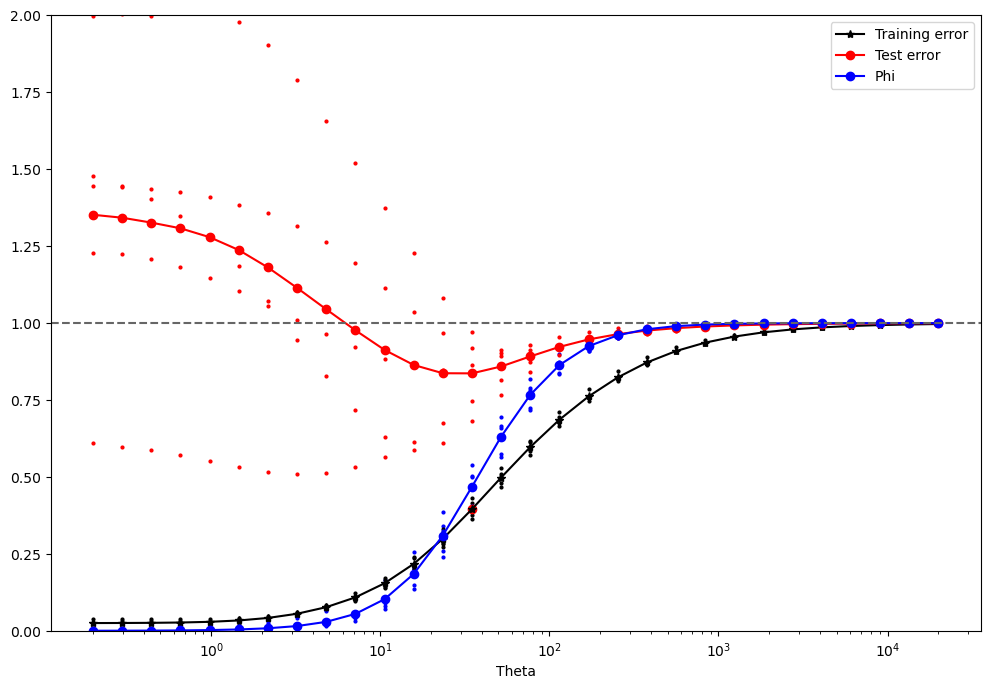

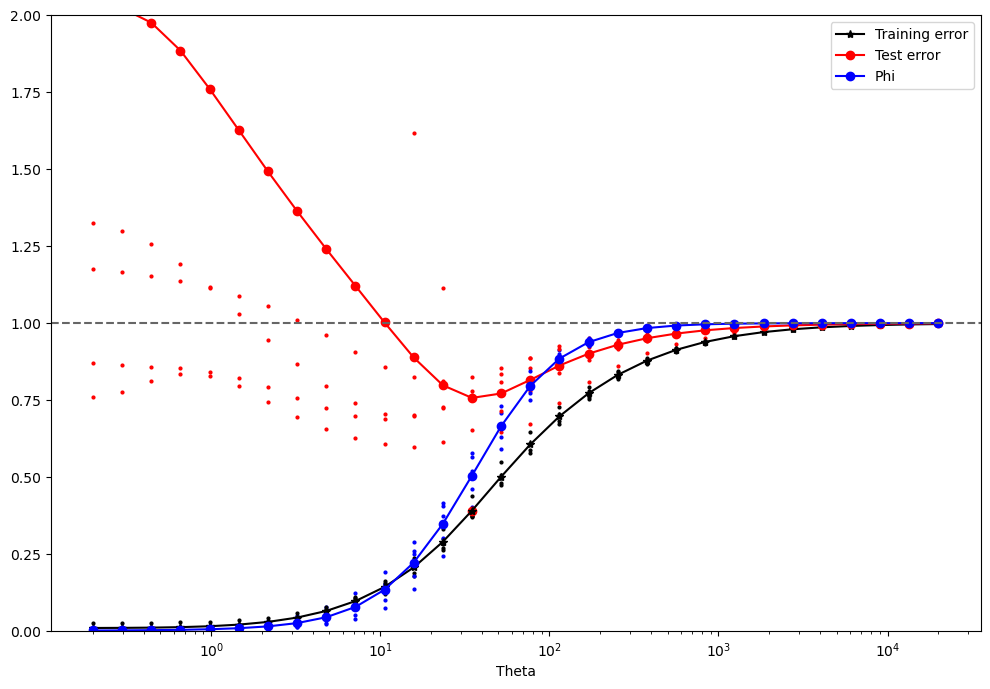

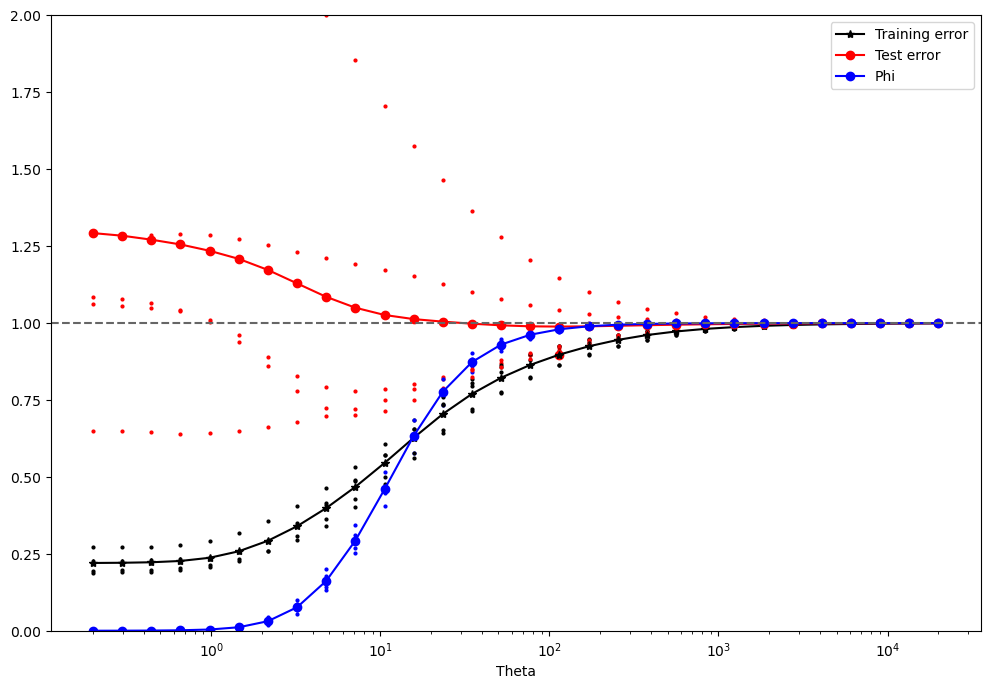

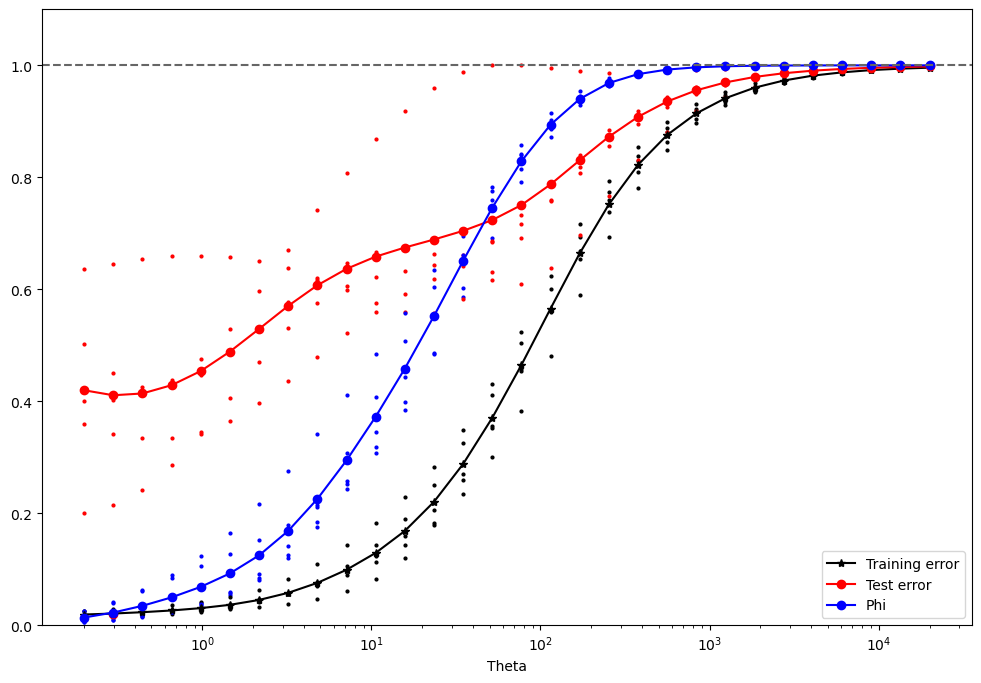

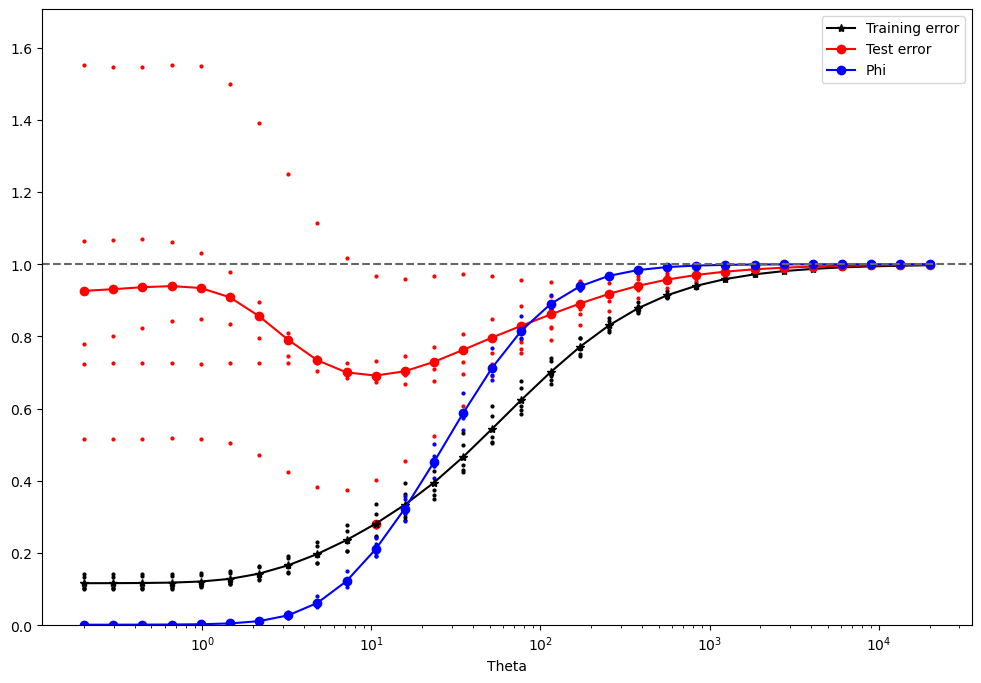

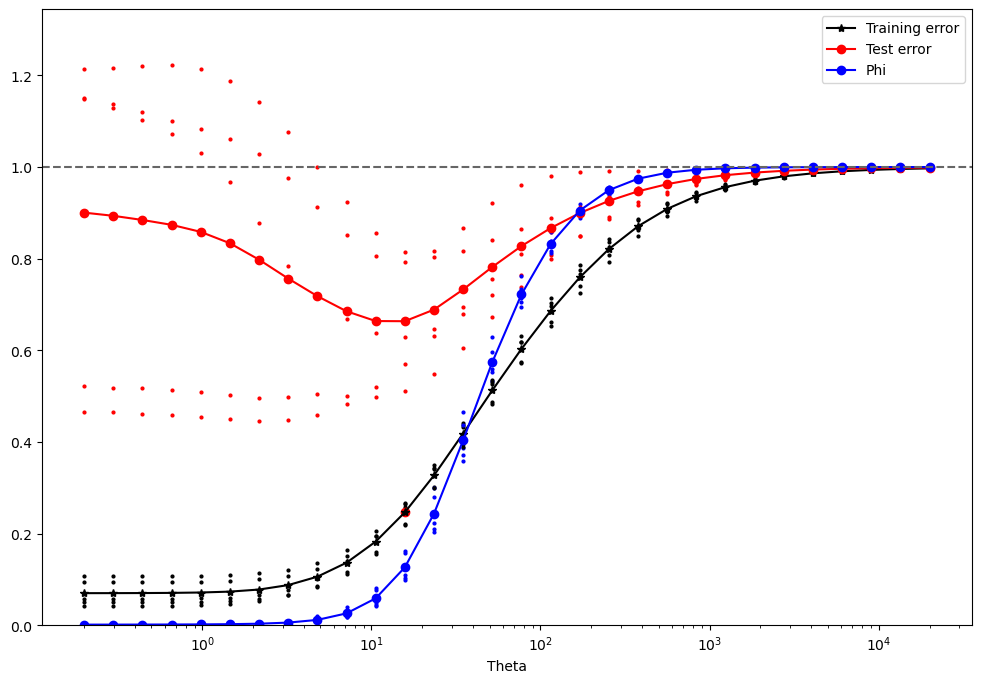

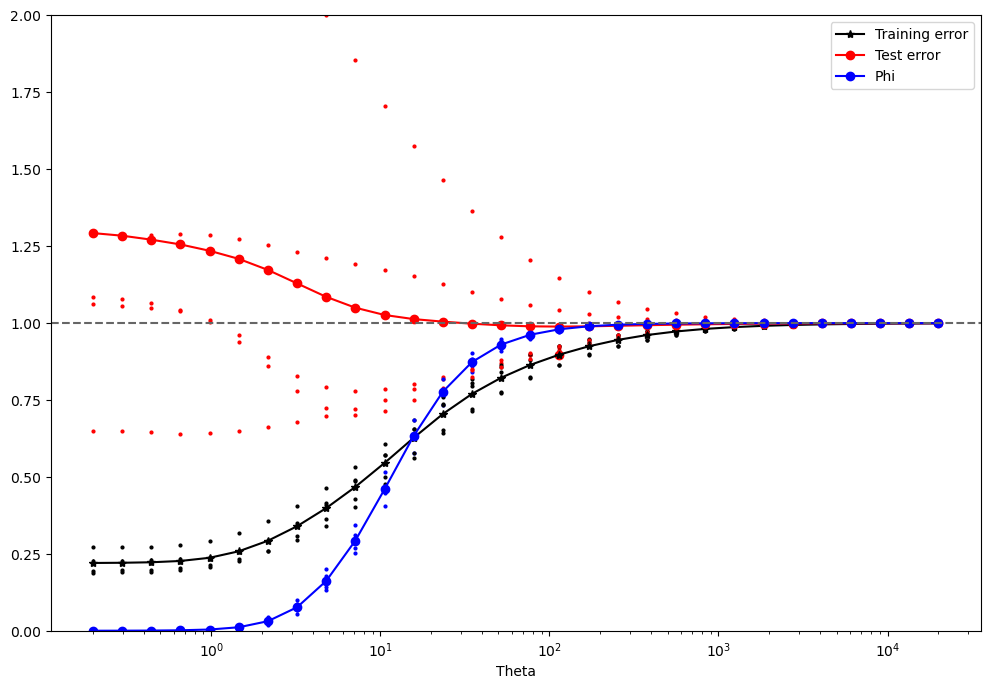

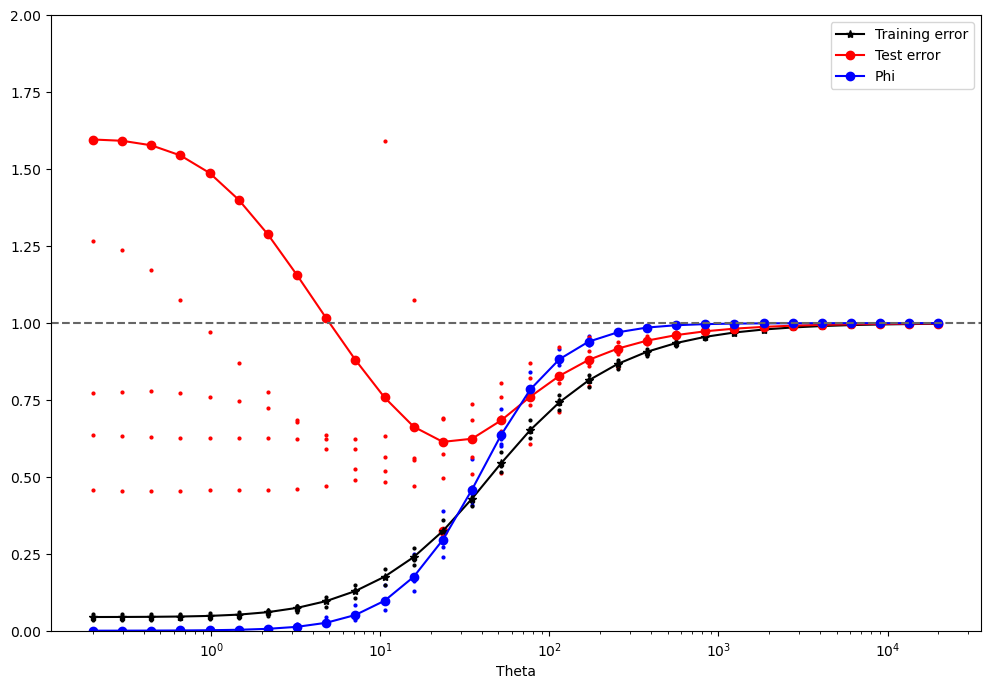

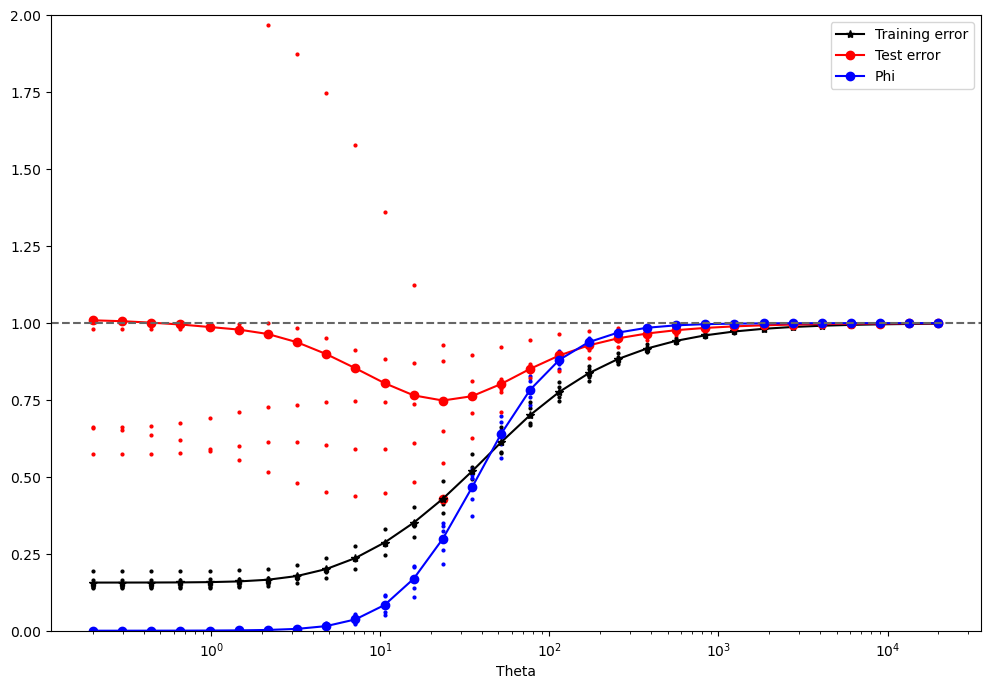

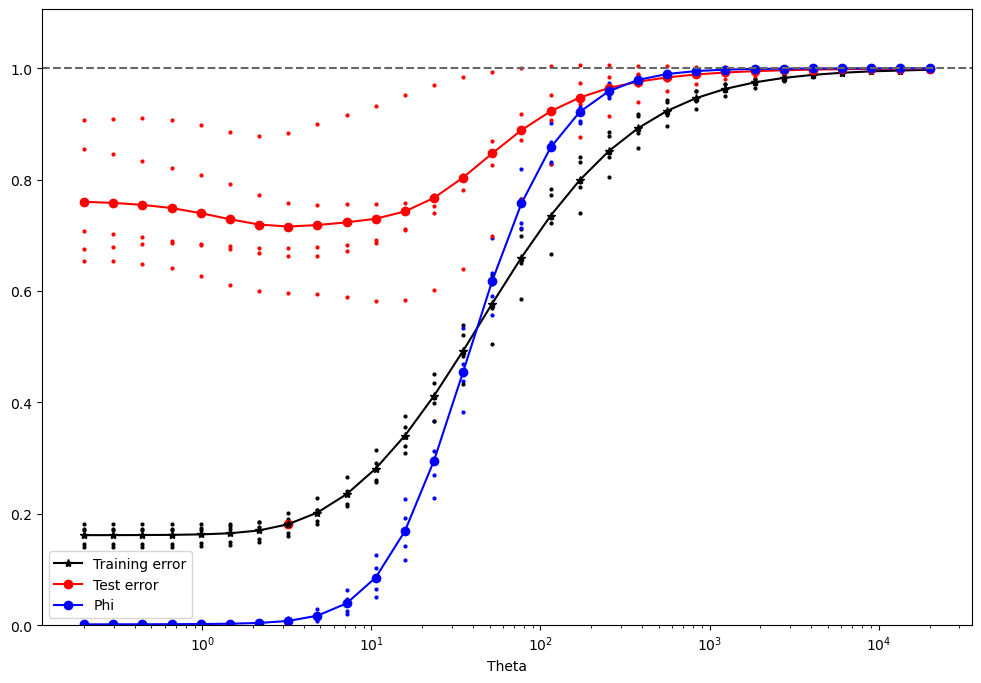

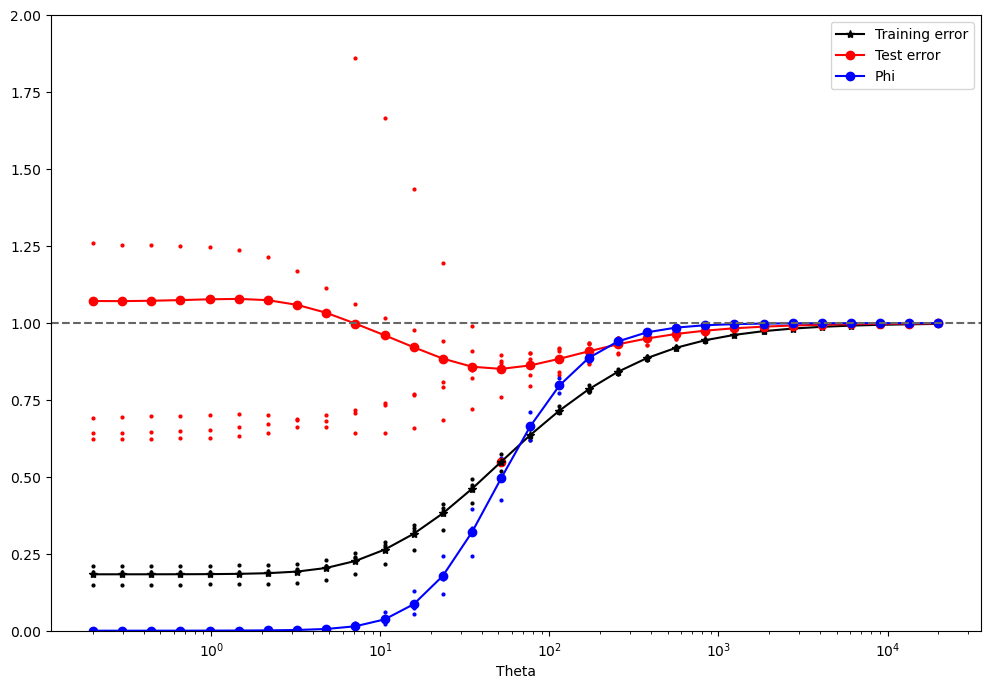

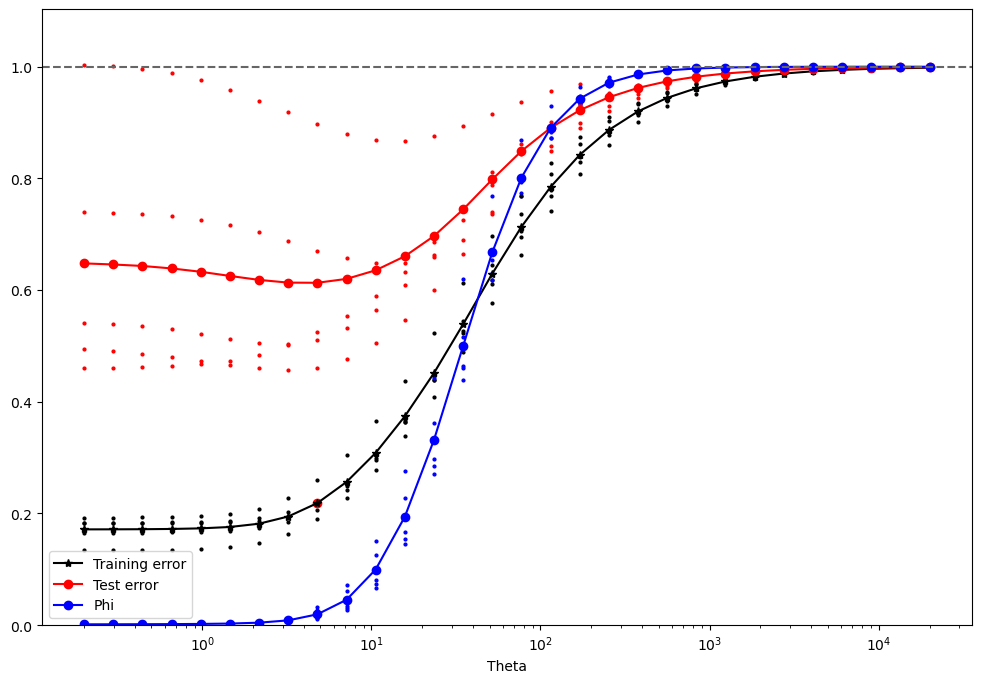

In [13]:

combinations = [ 
                 ["hcch", "j3"],
                 ["hcch", "rdc"],
                 ["hcn", "rdc"],
                 ["noe", "j3"],
                 ["hcp", "noe"],
                 ["hcp", "j3"],
                 ["hcp", "rdc"],
                 ["noe", "j3"],
                 ["noe", "rdc"],
                 ["rdc", "j3"],
                 ["hcch", "rdc", "j3"],
                 ["hcp", "rdc", "j3"],
                 ["noe","rdc", "j3"],
                ]
for c in combinations:
    tag = "_".join(c)
    print(tag)
    print([dt[typ] for typ in c])
for c in combinations:
    tag = "_".join(c)
    #print(f"Looking at combination: {tag}")
    r = Reweighter(tag, [dt[typ] for typ in c])
    # r.save_old_weights()
    r.scan_theta()
    r.reweight_and_save()
    # r.move_logs()

# Calculate Root Means Square Error and plot

In [ ]:
# Visualize RMSE compared to the different data types and 
def plot_rmse(tag,theta=50):
    weights_dir = f"crossval_{tag}"
    # Load reweighting results
    chi2 = np.load(f"{BME_FOLDER}/crossvals/{weights_dir}/chi2_results.npy")
    phis = np.load(f"{BME_FOLDER}/crossvals/{weights_dir}/phi_results.npy")
    weights = np.load(f"{BME_FOLDER}/crossvals/{weights_dir}/weights_results.npy")

    thetas = np.geomspace(0.1, 20000, 30)
    print(thetas)
    #print(phis, weights, chi2)
    tcp = np.array([thetas, chi2, phis],dtype="object").T
    w_np = np.array(weights)
    
    w0 = np.full(rdc_calc.shape[0], 1/rdc_calc.shape[0]) # sample weights

    # Calculate Root Means Square Error
    rmse_cv = []
    rmse_cv_init = np.array([calc_RMSE_ensemble(rdc_exp, rdc_calc[:,:]*L_calc, w0), calc_RMSE_ensemble(j3_exp, j3_calc[:,:], w0), calc_RMSE_ensemble(hcch_exp, hcch_calc[:,:], w0), calc_RMSE_ensemble(hcn_exp, hcn_calc[:,:], w0), calc_RMSE_ensemble(hcp_exp, hcp_calc[:,:], w0), calc_RMSE_ensemble(noe_exp, noe_calc[:,:], w0, noe=True)])
    for ww in w_np:
        rmse_cv.append(np.array([calc_RMSE_ensemble(rdc_exp, rdc_calc[:,:]*L_calc, ww), calc_RMSE_ensemble(j3_exp, j3_calc[:,:], ww), calc_RMSE_ensemble(hcch_exp, hcch_calc[:,:], ww), calc_RMSE_ensemble(hcn_exp, hcn_calc[:,:], ww), calc_RMSE_ensemble(hcp_exp, hcp_calc[:,:], ww), calc_RMSE_ensemble(noe_exp, noe_calc[:,:], ww, noe=True)])/rmse_cv_init)
    rmse_cv = np.array(rmse_cv)
    ccc = ['#003f5c', '#58508d', '#bc5090', '#ff6361', '#ffa600', '#00FFFF', '#006400']
    plt.figure(figsize=[7,5])

    plt.plot(tcp[:,0], rmse_cv[:,0], marker='o', color=ccc[0], lw=2, markersize=9, label=r'rel. RMSE RDC')
    plt.plot(tcp[:,0], rmse_cv[:,1], marker='s', color=ccc[1], lw=2, markersize=8, label=r'rel. RMSE 3J')
    plt.plot(tcp[:,0], rmse_cv[:,2], marker='d', color=ccc[2], lw=2, markersize=9, label=r'rel. RMSE HCCH')
    plt.plot(tcp[:,0], rmse_cv[:,3], marker='d', color=ccc[3], lw=2, markersize=9, label=r'rel. RMSE HCN')
    plt.plot(tcp[:,0], rmse_cv[:,4], marker='d', color=ccc[4], lw=2, markersize=9, label=r'rel. RMSE HCP')
    plt.plot(tcp[:,0], rmse_cv[:,5], marker='H', color=ccc[5], lw=2, markersize=9, label=r'rel. RMSE NOE')
    plt.plot(tcp[:,0], tcp[:,2], marker='^', color=ccc[6], lw=2, markersize=9, label=r'$\phi_{eff}$')
    plt.axhline(1, ls='--', c='k', lw=3, alpha=.5, zorder=-1)

    plt.axvline(theta, ls="--")

    plt.xlim(tcp[:,0].min()*0.85,tcp[:,0].max()*1.2)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.xlabel(r'$\theta$', fontsize=18)
    plt.legend(fontsize=14, labelspacing=0.1)
    plt.xscale('log')

    plt.tight_layout()

    if not os.path.exists(f"plots/{tag}"):
        os.makedirs(f"plots/{tag}")


    plt.savefig(f'plots/{tag}/{weights_dir}_{theta}_rmse.pdf', facecolor='w')
    plt.savefig(f'plots/{tag}/{weights_dir}_{theta}_rmse.png', facecolor='w')
    # plt.show() show later in multiplot

    return f'plots/{tag}/{weights_dir}_rmse.png'






### Plot all reweights

[1.00000000e-01 1.52333050e-01 2.32053581e-01 3.53494298e-01
 5.38488647e-01 8.20296180e-01 1.24958219e+00 1.90352666e+00
 2.89970022e+00 4.41720180e+00 6.72885822e+00 1.02502750e+01
 1.56145565e+01 2.37861302e+01 3.62341376e+01 5.51965669e+01
 8.40826139e+01 1.28085610e+02 1.95116717e+02 2.97227246e+02
 4.52775330e+02 6.89726470e+02 1.05068137e+03 1.60053498e+03
 2.43814375e+03 3.71409873e+03 5.65779988e+03 8.61869913e+03
 1.31291273e+04 2.00000000e+04]
[1.00000000e-01 1.52333050e-01 2.32053581e-01 3.53494298e-01
 5.38488647e-01 8.20296180e-01 1.24958219e+00 1.90352666e+00
 2.89970022e+00 4.41720180e+00 6.72885822e+00 1.02502750e+01
 1.56145565e+01 2.37861302e+01 3.62341376e+01 5.51965669e+01
 8.40826139e+01 1.28085610e+02 1.95116717e+02 2.97227246e+02
 4.52775330e+02 6.89726470e+02 1.05068137e+03 1.60053498e+03
 2.43814375e+03 3.71409873e+03 5.65779988e+03 8.61869913e+03
 1.31291273e+04 2.00000000e+04]
[1.00000000e-01 1.52333050e-01 2.32053581e-01 3.53494298e-01
 5.38488647e-01 8.202

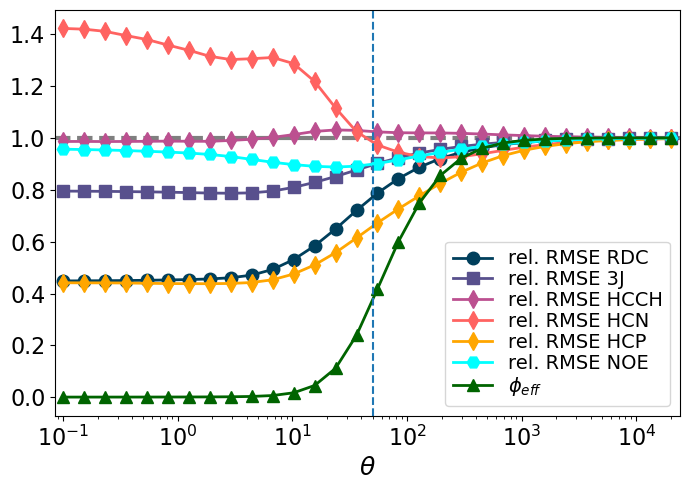

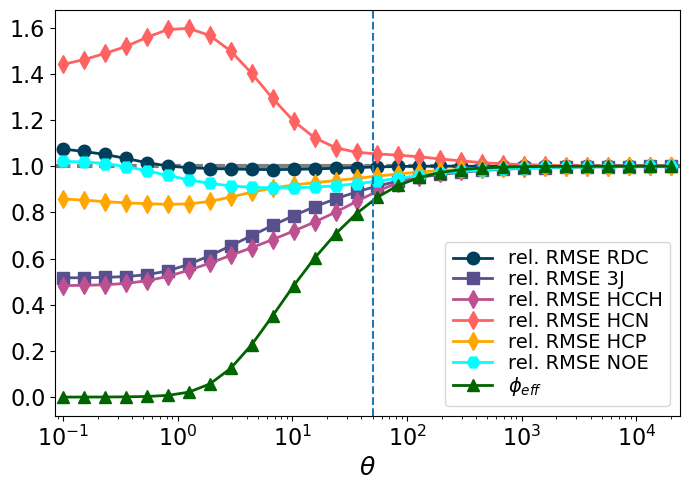

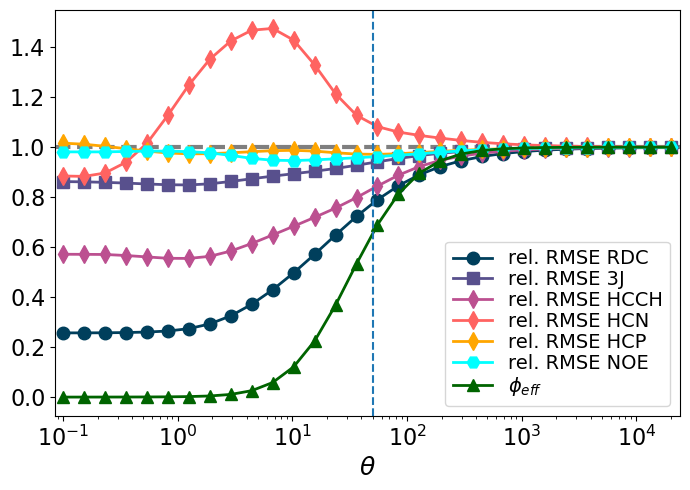

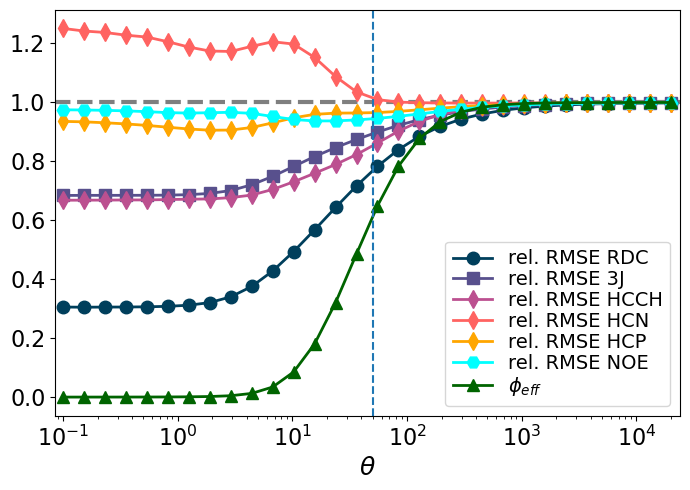

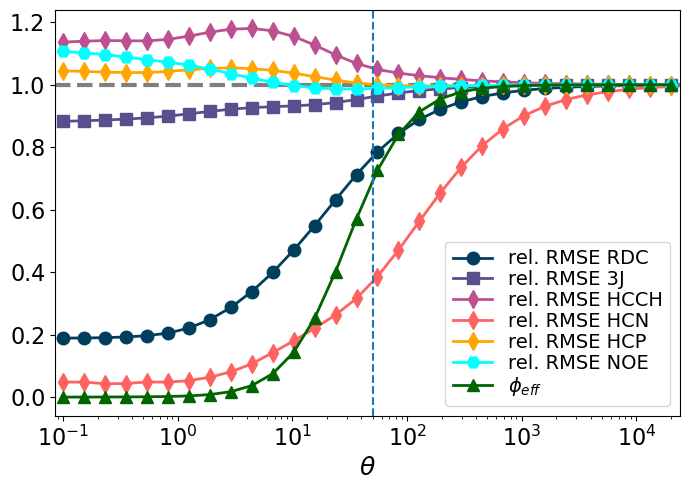

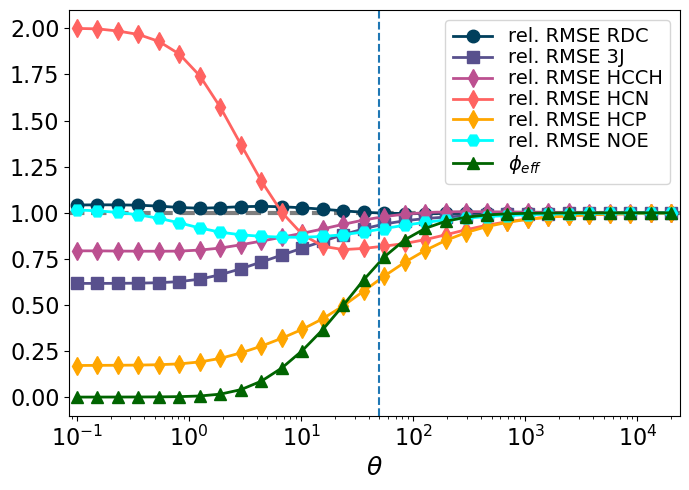

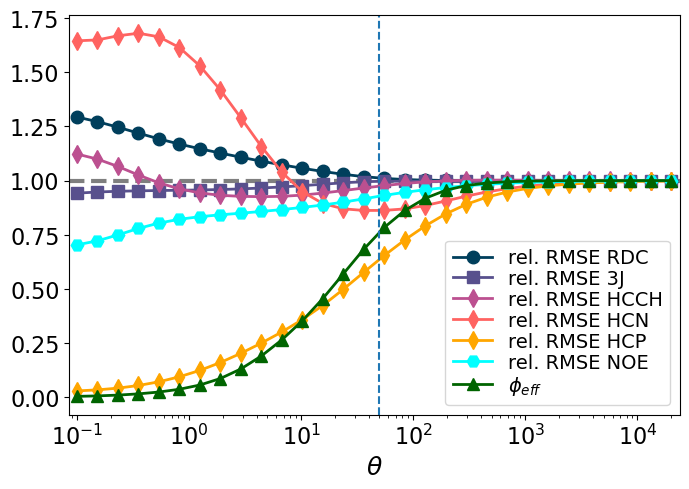

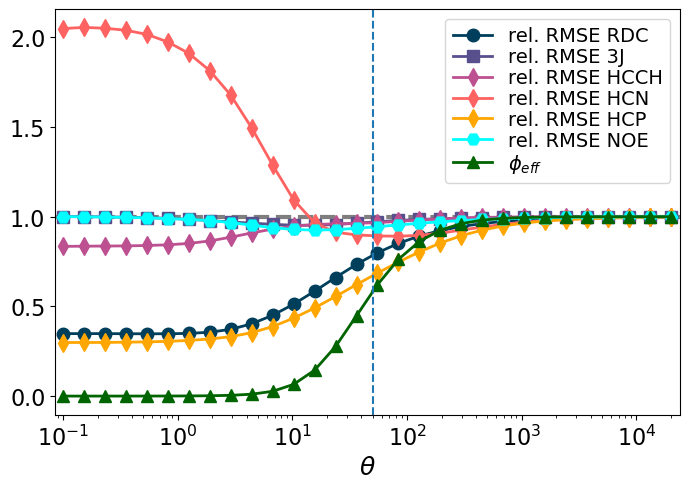

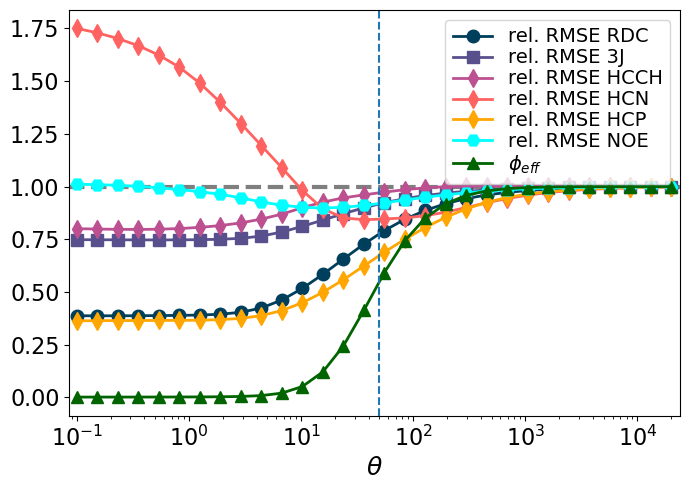

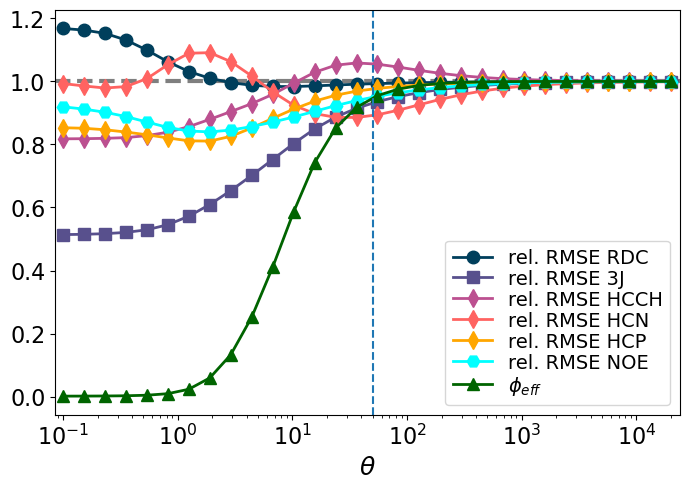

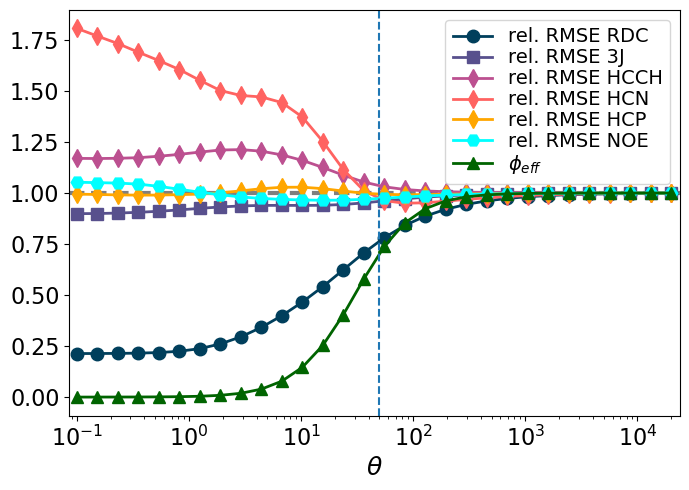

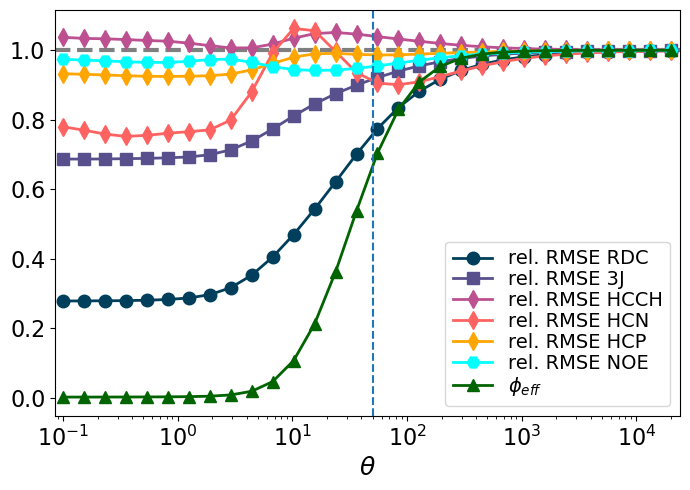

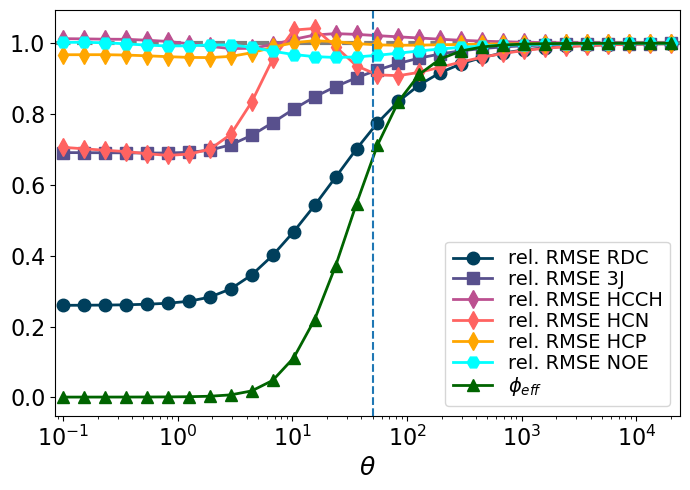

In [16]:

weight_dirs = [ f.name for f in os.scandir(f"{BME_FOLDER}/crossvals") if f.is_dir() and "crossval_" in f.name ]
plt_files = []
for w in weight_dirs:
    plt_files.append(plot_rmse(w.replace("crossval_","")))


### Compare partial Dataset and full dataset

[1.00000000e-01 1.52333050e-01 2.32053581e-01 3.53494298e-01
 5.38488647e-01 8.20296180e-01 1.24958219e+00 1.90352666e+00
 2.89970022e+00 4.41720180e+00 6.72885822e+00 1.02502750e+01
 1.56145565e+01 2.37861302e+01 3.62341376e+01 5.51965669e+01
 8.40826139e+01 1.28085610e+02 1.95116717e+02 2.97227246e+02
 4.52775330e+02 6.89726470e+02 1.05068137e+03 1.60053498e+03
 2.43814375e+03 3.71409873e+03 5.65779988e+03 8.61869913e+03
 1.31291273e+04 2.00000000e+04]
[1.00000000e-01 1.52333050e-01 2.32053581e-01 3.53494298e-01
 5.38488647e-01 8.20296180e-01 1.24958219e+00 1.90352666e+00
 2.89970022e+00 4.41720180e+00 6.72885822e+00 1.02502750e+01
 1.56145565e+01 2.37861302e+01 3.62341376e+01 5.51965669e+01
 8.40826139e+01 1.28085610e+02 1.95116717e+02 2.97227246e+02
 4.52775330e+02 6.89726470e+02 1.05068137e+03 1.60053498e+03
 2.43814375e+03 3.71409873e+03 5.65779988e+03 8.61869913e+03
 1.31291273e+04 2.00000000e+04]


'plots/hcp_rdc_j3/crossval_hcp_rdc_j3_rmse.png'

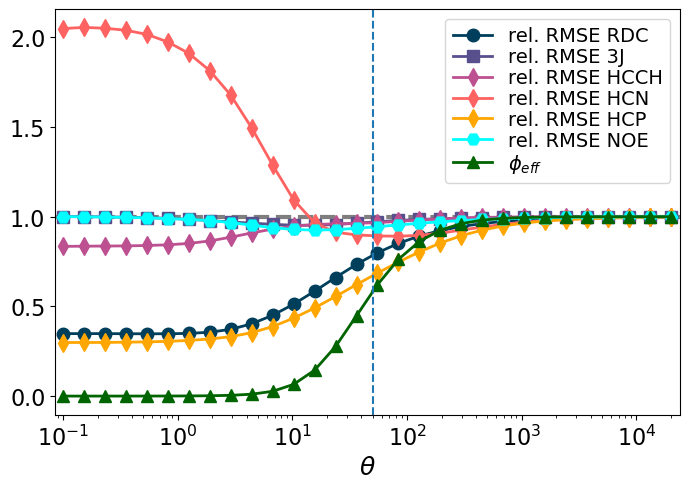

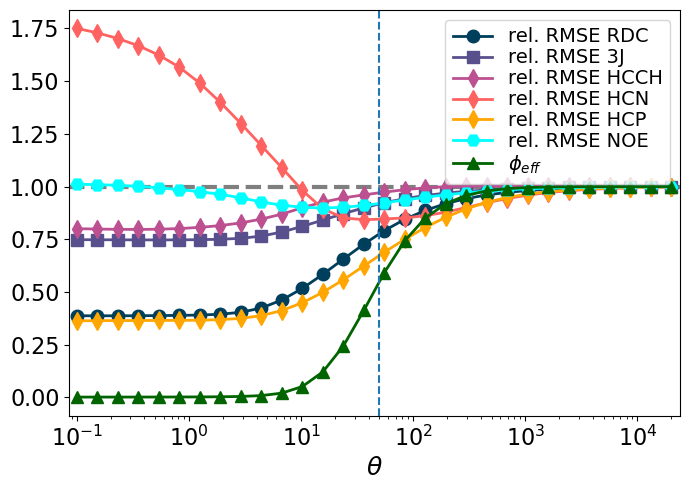

In [20]:
tag = "hcp_rdc"
plot_rmse(tag)
tag = "hcp_rdc_j3"
plot_rmse(tag)

## Final reweighting

[1.00000000e-01 1.52333050e-01 2.32053581e-01 3.53494298e-01
 5.38488647e-01 8.20296180e-01 1.24958219e+00 1.90352666e+00
 2.89970022e+00 4.41720180e+00 6.72885822e+00 1.02502750e+01
 1.56145565e+01 2.37861302e+01 3.62341376e+01 5.51965669e+01
 8.40826139e+01 1.28085610e+02 1.95116717e+02 2.97227246e+02
 4.52775330e+02 6.89726470e+02 1.05068137e+03 1.60053498e+03
 2.43814375e+03 3.71409873e+03 5.65779988e+03 8.61869913e+03
 1.31291273e+04 2.00000000e+04]


'plots/hcp_rdc_j3/crossval_hcp_rdc_j3_rmse.png'

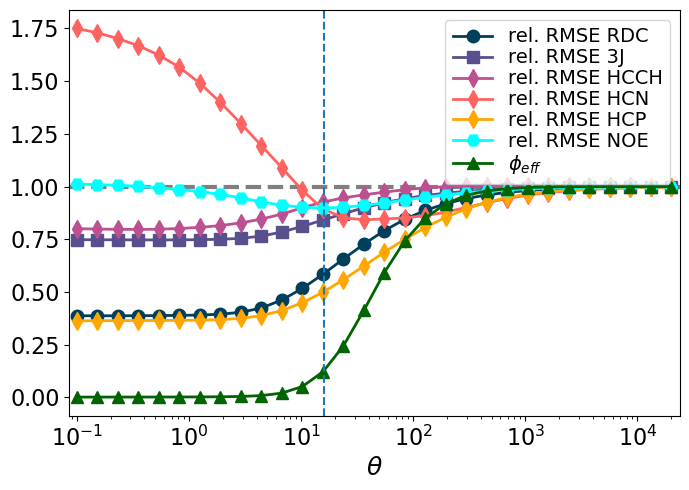

In [17]:
theta = 16
tag = f"hcp_rdc_j3" #_theta={theta}"
plot_rmse(tag, theta)

## Reweight with selected (optimal) $\theta$

In [22]:
tags = ["hcp", "rdc", "j3"]
t = 16
r = Reweighter(f"hcp_rdc_3j_theta={t}",[dt[typ] for typ in tags], thetas = [t])
r.reweight_and_save()
r.move_logs()

Fitting
Saving new weights at bme_reweight/crossvals/crossval_hcp_rdc_3j_theta=16
